In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import pandas as pd

In [2]:
# read in
folder = Path('./output/2025-11-26_12h39m58s_classif_grid5_norms')

# subfolders = ['t1','t2','t3']
# dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
# test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

dev = pd.read_csv(folder/'dev.csv')
test = pd.read_csv(folder/'test.csv')

# get confs
config_names = dev['config'].unique().tolist()
confs = ConfigLookup(
    keys=['norm_class'],
    configs=config_names,
    path=folder,
    save=True
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

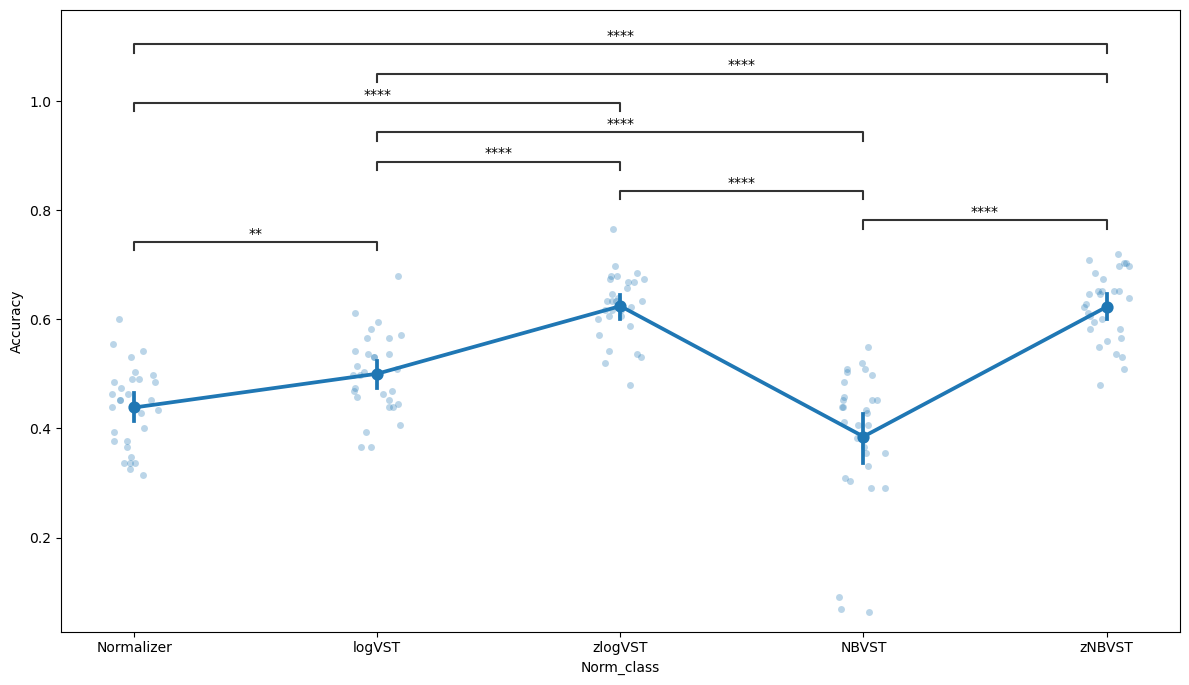

In [37]:
metric_x_point(
    df=test,
    cols=['norm_class'],
    metrics=['accuracy'],#,'time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True
)

In [38]:
filt = test[test['norm_class'] != 'Normalizer'].copy()
filt['z'] = filt['norm_class'].str[0] == 'z'
filt['norm'] = filt['norm_class'].str.replace('|'.join(['z','VST']),'',regex=True)
filt

,norm_class,config,trial,metric,value,z,norm
210,logVST,normclassLogVST,0,loss,1.060517,False,log
211,logVST,normclassLogVST,0,accuracy,0.457143,False,log
212,logVST,normclassLogVST,0,precision,0.516722,False,log
213,logVST,normclassLogVST,0,recall,0.540278,False,log
214,logVST,normclassLogVST,0,f1,0.464801,False,log
...,...,...,...,...,...,...,...
1045,zNBVST,normclassZNBVST,29,precision,0.535780,True,NB
1046,zNBVST,normclassZNBVST,29,recall,0.518243,True,NB
1047,zNBVST,normclassZNBVST,29,f1,0.485795,True,NB
1048,zNBVST,normclassZNBVST,29,auroc,0.839158,True,NB


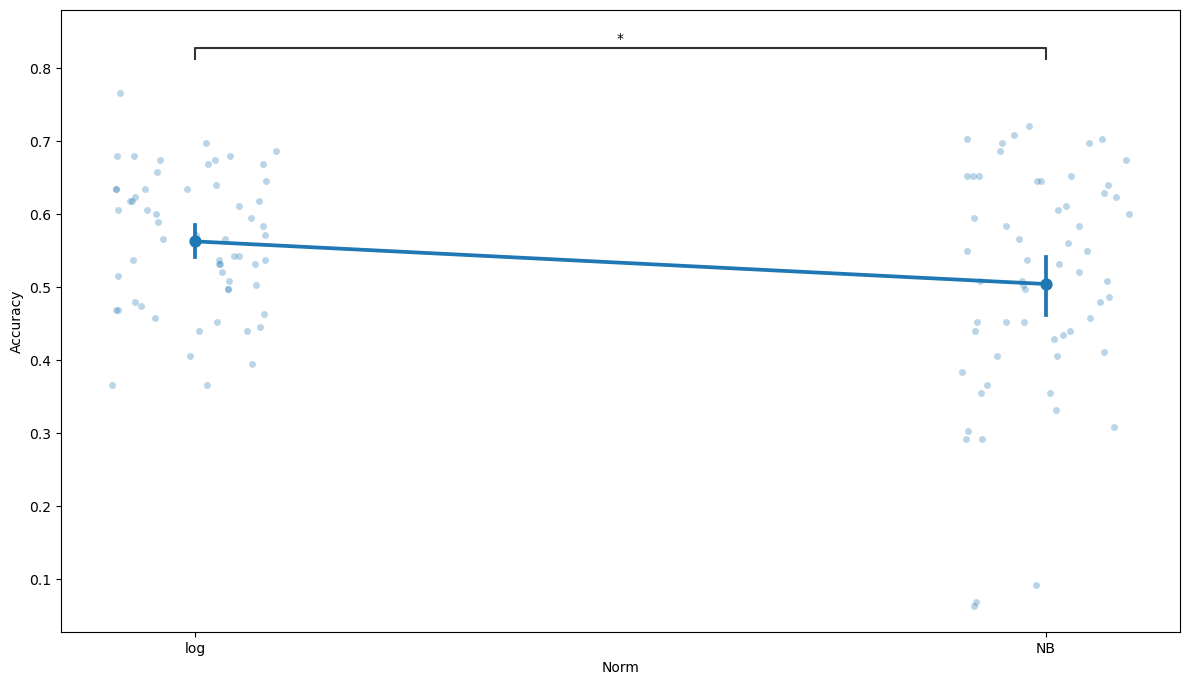

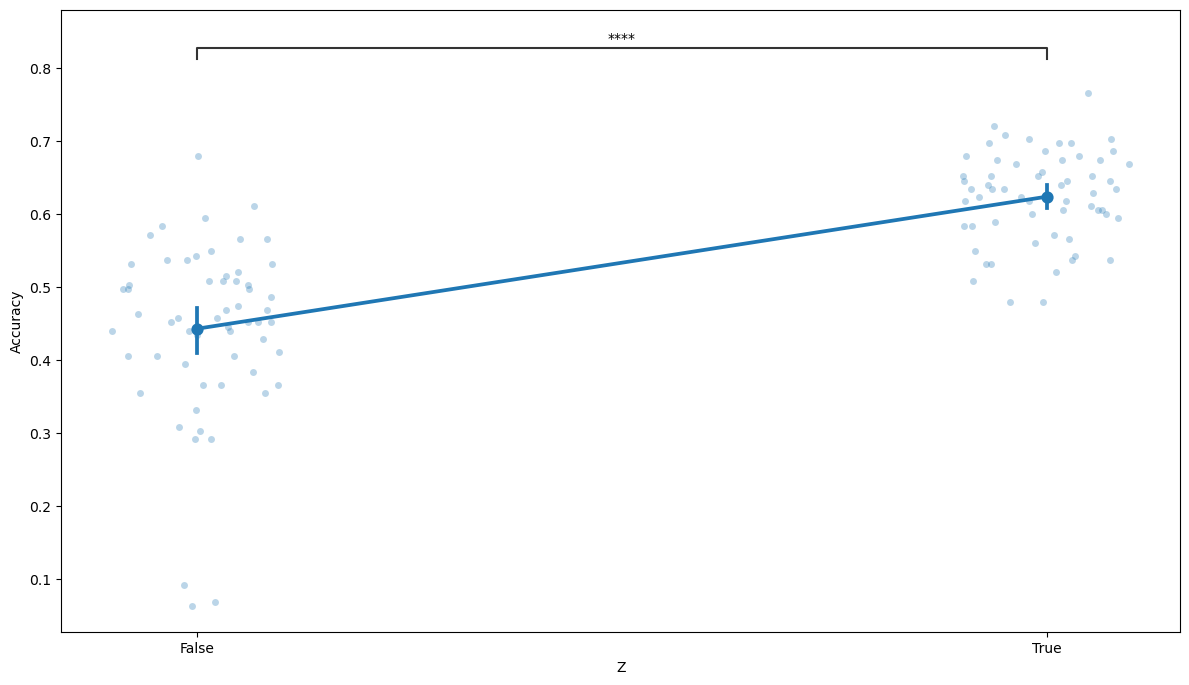

In [41]:
metric_x_point(
    df=filt,
    cols=['norm','z'],
    metrics=['accuracy'],#,'time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True
)

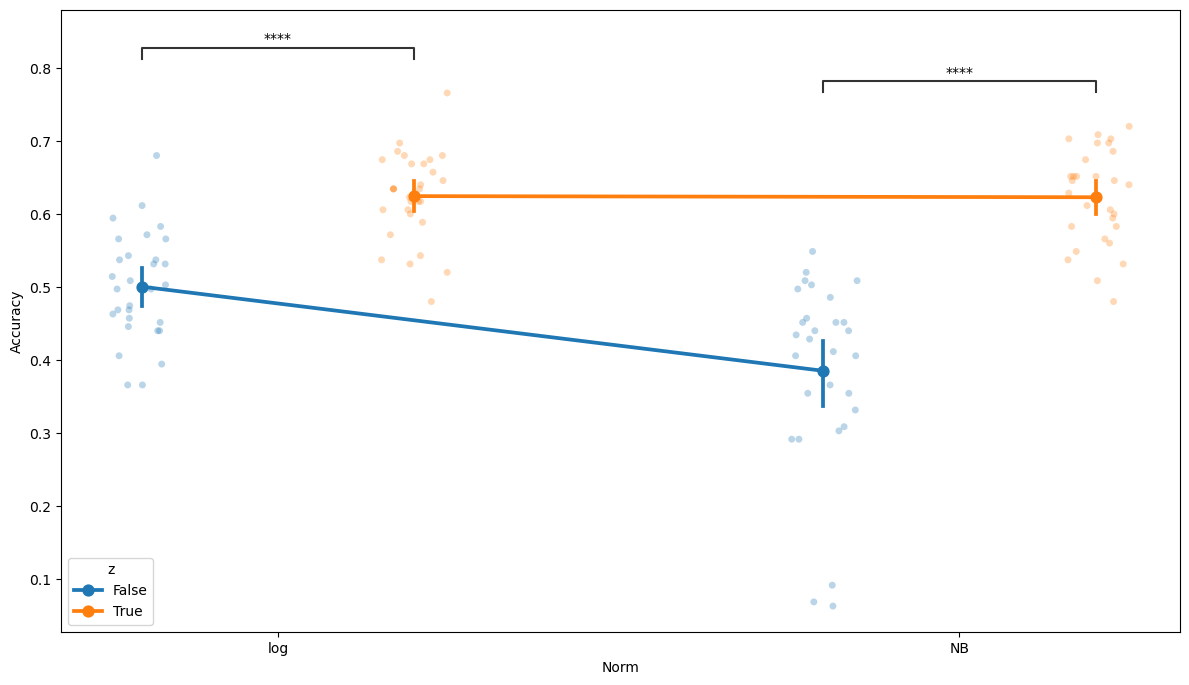

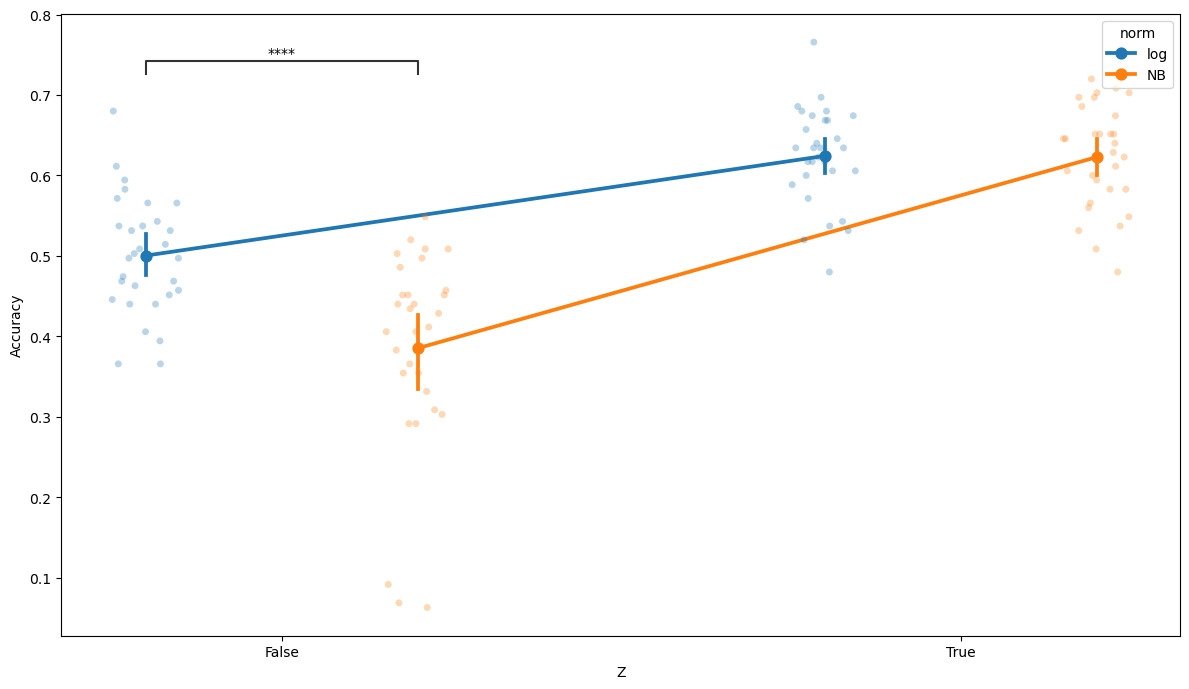

In [43]:
metric_x_point(
    df=filt,
    cols=['norm','z'],
    metrics=['accuracy'],#,'time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
    hue=True
)

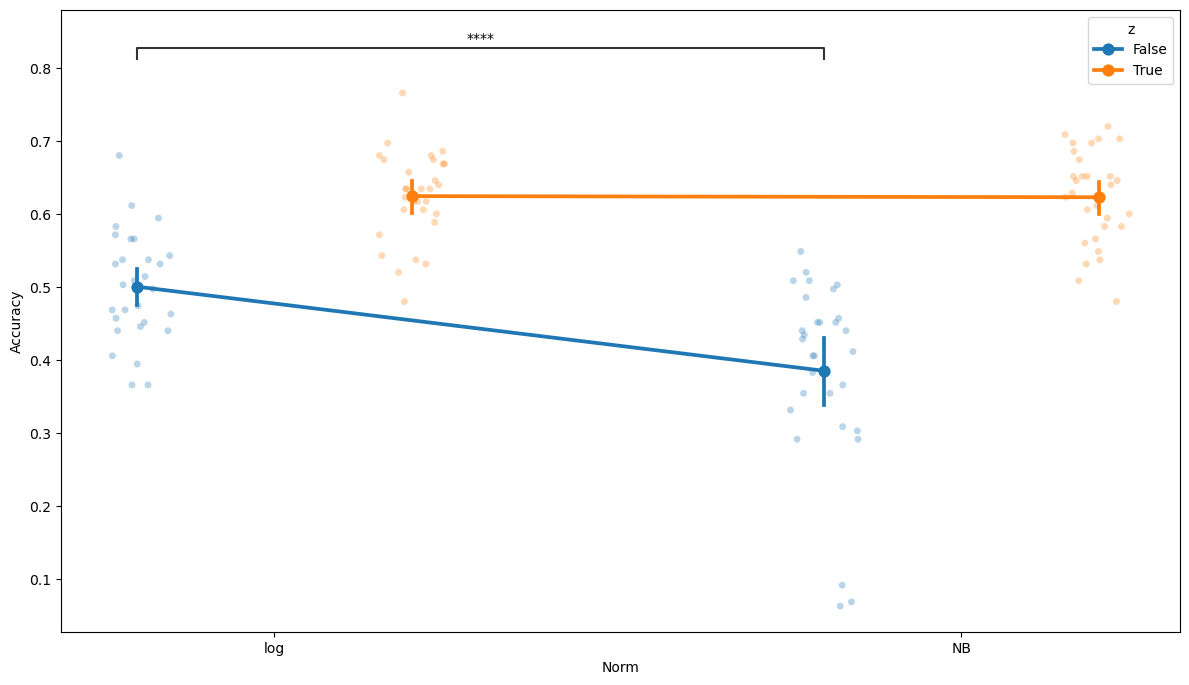

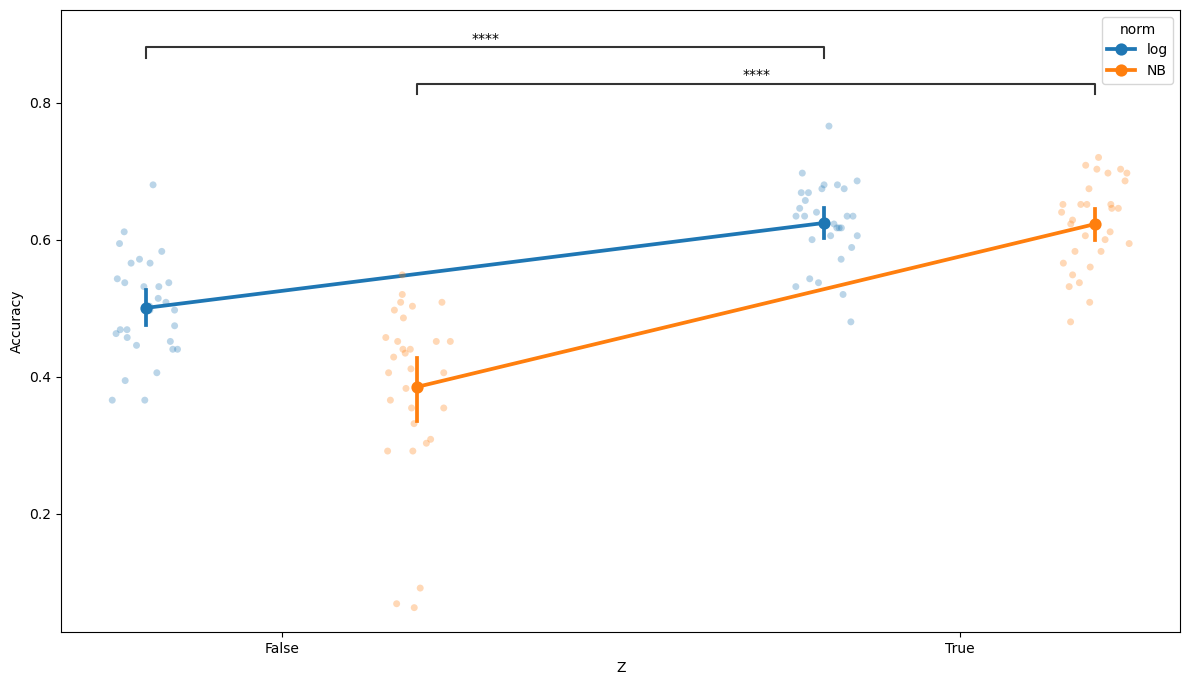

In [45]:
metric_x_point(
    df=filt,
    cols=['norm','z'],
    metrics=['accuracy'],#,'time'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True,
    hue=True,
    sig='between'
)

---

In [4]:
import torch

In [5]:
torch.zeros(0)

tensor([])